# Chapter 7: Bitcoin — 재현보다 먼저 검증할 것들

공식 Chapter 7 archive의 BTC minute BBO, daily close, Bitstamp trade tick을 사용해 위험, AR/ADF, Bollinger, bagged tree, order flow, 거래소 간 차익거래를 살펴본다. 목표는 높은 역사적 CAGR을 다시 보여 주는 데 있지 않다. 어떤 결과가 원본과 정확히 일치하고, 어떤 결과가 estimator 차이 때문에 근사이며, 어떤 코드는 입력이나 실행 계약 부족으로 output-only인지 분리한다. 이 노트북은 연구 코드를 감사하는 역사적 백테스트 실험이지 현재 Bitcoin 투자 추천이 아니다.

In [1]:
from io import BytesIO
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
sys.path.insert(0, str(Path.cwd()))
import run_chapter7_analysis as ch7
data=ch7.load_data()
results=ch7.run_experiments(data)
checks=ch7.verify_results(data,results)
metrics=ch7.build_metrics(data,results,checks)
print(f"minute={len(data.mid):,}, trades={len(data.trades):,}, checks={sum(checks.values())}/{len(checks)}")

minute=479,535, trades=119,914, checks=25/25


## 1. 문제 정의와 학습 질문

첫째, crypto의 fat tail과 drawdown은 전통자산보다 어떤 위험을 추가하는가? 둘째, AR lag 선택과 ADF 결론은 estimator와 sample split에 얼마나 민감한가? 셋째, 예측력이 있어 보이는 minute 전략이 spread와 turnover cost 후에도 남는가? 넷째, timestamp 저장 단위와 자정 경계가 order-flow state machine을 어떻게 바꾸는가? 다섯째, cross-exchange spread를 보이는 숫자 그대로 수익으로 간주할 수 있는가?

In [2]:
def show_figure(fig):
    payload=BytesIO(); fig.savefig(payload,format='png',dpi=120,bbox_inches='tight'); plt.close(fig); display(Image(data=payload.getvalue()))
pd.DataFrame(ch7.coverage_matrix())

,topic,status,evidence
0,BTC daily tail risk,independent source-data replay,345 daily closes
1,"AR(16), ADF, and forecast strategy",approximate replay + look-ahead audit,"479,535 minute mids and printed coefficients"
2,AR/ARMA BIC selection,diagnostic + output-only source order,"Yule-Walker AR(15) versus MATLAB MLE AR(16), A..."
3,Bollinger mean reversion,exact source replay,three published outputs
4,bagged regression trees,deterministic source-semantic adaptation,chronological half split and execution-cost st...
5,SVM and neural networks,code/output-only,nonportable MATLAB training defaults
6,Bitstamp order flow,exact source replay,31 daily rows and three aggregate outputs
7,cross-exchange arbitrage,historical arithmetic illustration,book example; credit and transfer risk unquant...


## 2. provenance, checksum, environment version

공식 source URL, archive SHA-256, 12개 member의 개별 checksum, uv.lock SHA와 패키지 버전을 기록한다. online 실행은 archive를 검증해 materialize하고 offline 실행은 이미 받은 파일을 전수 검사한다. 재현성은 코드만 보관하는 것이 아니라 입력 byte, 환경, random seed를 함께 고정하는 일이다.

In [3]:
pd.Series({**metrics['provenance'],'uv_lock_sha256':metrics['environment']['uv_lock_sha256'],'versions':metrics['environment']['versions']})

source_page                                     https://epchan.com/book3
archive_url             https://epchan.com/img/book3/Chap7%20Bitcoin.zip
archive_sha256         03267f6abd2fa35325d915e43677265b8b90da93fea0a0...
archive_size_bytes                                               3130126
member_count                                                          12
matlab_source_count                                                    9
research_data_count                                                    3
manifest_sha256        93ce3ef2abd79c7512e50d0c2b54ceeb1c3c40fcf5cba8...
uv_lock_sha256         34057457773a614f058648f3ba9ba2f02f02354f64214e...
versions               {'python': '3.12.3', 'numpy': '2.5.1', 'pandas...
dtype: object

## 3. 재현 상태와 coverage matrix

`exact source replay`는 출판된 원본 출력과 엄격한 tolerance로 비교한다. `approximate replay`는 계산 의미는 가깝지만 MATLAB MLE/JPL 구현과 Python이 달라 허용오차와 이유를 공개한다. `source-semantic adaptation`은 같은 feature와 split을 현대 library에 옮기되 숫자 동등성을 주장하지 않는다. `output-only`는 원본 숫자를 기록만 하고 실행 결과로 가장하지 않는다. 이 분류가 구현 범위와 증거를 연결한다.

In [4]:
pd.Series(metrics['reproduction_classification']).apply(lambda x:', '.join(x))

exact_source_replay                                   bollinger.m, orderFlow2.m
approximate_replay                    buildARp_BTCUSD.m conditional OLS and ADF
source_semantic_adaptation                     rTreeBagger_BTCUSD.m via sklearn
output_only                   AR and ARMA lag selection, MATLAB TreeBagger r...
dtype: str

## 4. 데이터 구조와 결측·호가 진단

minute midpoint 479,535행은 finite지만 `HHMM` 보조 배열은 13,438행뿐이고, bid가 ask보다 큰 crossed row가 517개다. 원본 전략은 midpoint와 날짜를 사용하므로 실행할 수 있지만 호가 데이터가 깨끗하다는 뜻은 아니다. daily close는 345행, Bitstamp CSV는 119,914 tick과 31일을 담는다. timestamp는 시간순이며 aggressor tag는 -1, 0, 1만 허용한다. shape mismatch와 crossed quote를 임의 정제하지 않고 provenance 진단으로 보존한다.

In [5]:
pd.DataFrame(metrics['data']).T

,rows,date_start,date_end,crossed_quote_rows,hhmm_rows,hhmm_matches_price_rows,days
minute_bbo,479535,20140120,20150115,517,13438,False,NaN
daily_btc,345.0,20140120.0,20150114.0,NaN,NaN,NaN,NaN
bitstamp_trades,119914,2014-12-01 00:00:05.869999,2014-12-31 23:59:44.885999,NaN,NaN,NaN,31


## 5. BTC tail risk

변동성만으로 crypto 위험을 요약할 수 없다. daily wealth $W_t=P_t/P_0$와 drawdown

$$DD_t=\frac{W_t}{\max_{s\le t} W_s}-1$$

을 함께 계산한다. 표본의 최대 낙폭은 약 -79%, 최악 일간수익률은 약 -24%다. 높은 kurtosis와 거래소 운영 위험은 정규분포 기반 position sizing의 취약점을 드러낸다.

annualized_volatility    6.735689e-01
best_daily_return        1.968247e-01
best_date                2.014030e+07
worst_daily_return      -2.448899e-01
worst_date               2.015011e+07
maximum_drawdown        -7.923083e-01
annualized_kurtosis      7.230567e+00
period_start             2.014012e+07
period_end               2.015011e+07
dtype: float64

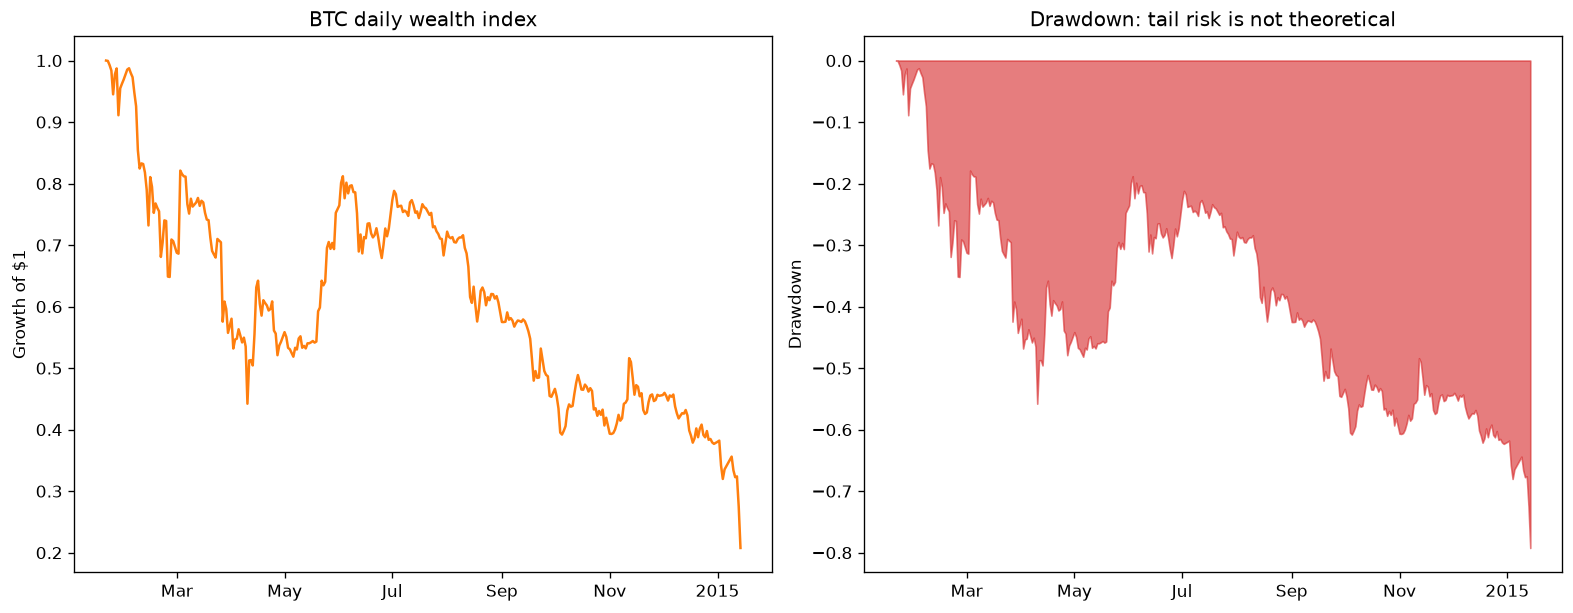

In [6]:
display(pd.Series(metrics['results']['risk'])); show_figure(ch7.plot_risk(data,results))

## 6. 수식 → 코드: AR forecast와 ADF

AR($p$) 예측은

$$\hat P_{t+1}=c+\sum_{j=1}^{p}\phi_j P_{t+1-j}$$

이며 예측이 현재 가격보다 높으면 long, 낮으면 short를 잡고 다음 bar 수익에 position을 lag한다. `fit_ar_conditional()`은 normal equation을 streaming-like gram matrix로 구성해 거대한 dense lag matrix를 피한다. `adf_one_lag()`는 상수, lagged level, 한 개 lagged difference를 OLS로 적합한다. 원본 JPL ADF와 통계량이 가까워도 동일 library 재현은 아니다.

In [7]:
pd.Series({'python_yule_walker_lag':results['ar']['yule_walker_selected_lag'],'source_matlab_mle_lag':results['ar']['source_selected_lag'],'adf_statistic':results['ar']['adf']['statistic'],'source_5pct_critical':results['ar']['adf']['critical_value_5pct_source']})

python_yule_walker_lag    15.000000
source_matlab_mle_lag     16.000000
adf_statistic             -3.000998
source_5pct_critical      -2.871000
dtype: float64

## 7. AR lag selection과 look-ahead audit

MATLAB Gaussian MLE BIC는 AR(16)을 고르지만 Python Yule-Walker BIC는 AR(15)을 고른다. estimator가 다르면 likelihood와 penalty 대상이 달라져 selection도 바뀐다. 더 중요한 문제는 원본이 train에서 lag를 고른 뒤 전체 `mid`로 계수를 다시 적합한다는 점이다. 이는 test price가 계수에 들어가는 look-ahead다. source-faithful curve와 train-only correction을 나란히 두어 이 차이를 숨기지 않는다.

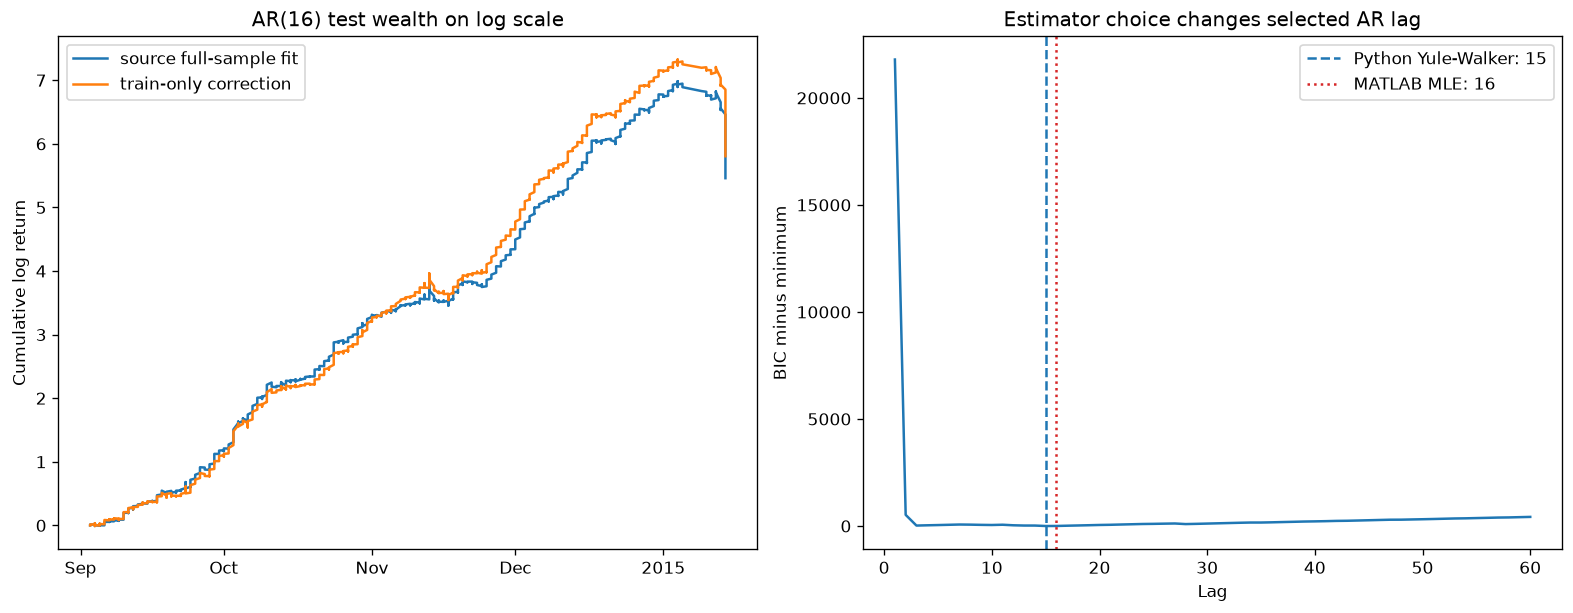

In [8]:
show_figure(ch7.plot_ar(data,results))

## 8. 원본 MATLAB 비교

AR의 17개 coefficient, ADF statistic, test cumulative/annual return은 구현 차이를 반영한 `approximate` tolerance로 비교한다. Bollinger 세 숫자와 order flow 세 aggregate는 `exact` tolerance로 비교한다. tolerance는 결과를 통과시키기 위해 임의로 넓히는 값이 아니라 원본 표시 정밀도와 알고리즘 차이를 문서화한 계약이다.

In [9]:
pd.DataFrame(metrics['book_comparisons'])[['topic','metric','python','source','absolute_error','tolerance','classification','matches_source']]

,topic,metric,python,source,absolute_error,tolerance,classification,matches_source
0,buildARp_BTCUSD.m,constant,0.006706,0.006706,4.589885e-09,5.000000e-07,approximate conditional OLS versus MATLAB Gaus...,True
1,buildARp_BTCUSD.m,AR{1},0.685261,0.685261,1.989742e-07,5.000000e-07,approximate conditional OLS versus MATLAB Gaus...,True
2,buildARp_BTCUSD.m,AR{2},0.257702,0.257702,7.196021e-08,5.000000e-07,approximate conditional OLS versus MATLAB Gaus...,True
3,buildARp_BTCUSD.m,AR{3},0.058041,0.058041,2.731778e-08,5.000000e-07,approximate conditional OLS versus MATLAB Gaus...,True
4,buildARp_BTCUSD.m,AR{4},0.004432,0.004432,2.906311e-09,5.000000e-07,approximate conditional OLS versus MATLAB Gaus...,True
5,buildARp_BTCUSD.m,AR{5},-0.003400,-0.003400,3.811669e-09,5.000000e-07,approximate conditional OLS versus MATLAB Gaus...,True
6,buildARp_BTCUSD.m,AR{6},-0.004966,-0.004966,2.454649e-09,5.000000e-07,approximate conditional OLS versus MATLAB Gaus...,True
7,buildARp_BTCUSD.m,AR{7},-0.010618,-0.010618,2.294181e-08,5.000000e-07,approximate conditional OLS versus MATLAB Gaus...,True
8,buildARp_BTCUSD.m,AR{8},-0.001899,-0.001899,2.785001e-09,5.000000e-07,approximate conditional OLS versus MATLAB Gaus...,True
9,buildARp_BTCUSD.m,AR{9},0.003264,0.003264,4.217291e-09,5.000000e-07,approximate conditional OLS versus MATLAB Gaus...,True


## 9. Bollinger exact replay

60분 평균 $m_t$와 표본 표준편차 $s_t$에 대해 $P_t\le m_t-2s_t$이면 long, $P_t\ge m_t+2s_t$이면 short에 진입하고 평균선에서 청산한다. Pandas rolling std가 `ddof=1`일 때만 원본 세 결과와 정확히 일치한다. position은 signal이 관측된 다음 bar return에 적용한다. gross test 수익은 플러스지만 10bp per turnover를 넣으면 거의 -100%가 된다.

In [10]:
pd.DataFrame({'gross':results['bollinger']['test'],'net_10bps':results['bollinger']['test_net_10bps']}).T

,annual_return,annual_return_log,sharpe,maximum_drawdown,drawdown_duration,cumulative_return,cumulative_return_log,periods,periods_per_year
gross,0.442459,0.366349,0.868609,-0.462587,141606.0,0.201024,0.183175,181440.0,362880.0
net_10bps,-0.999974,-10.562375,-14.185168,-0.995160,181423.0,-0.994914,-5.281187,181440.0,362880.0


## 10. Bollinger 거래비용·슬리피지

원본은 midpoint에서 즉시 체결되고 latency와 impact가 없다고 가정한다. 비용식은

$$r_t^{net}=r_t-0.001\lvert q_t-q_{t-1}\rvert$$

이다. turnover가 잦으면 작은 평균회귀 edge보다 비용이 훨씬 크다. 실제 market order는 spread와 slippage를 추가로 부담하고, limit order는 미체결과 adverse selection을 부담한다. 따라서 비용 없는 CAGR을 실전 기대수익으로 읽으면 안 된다.

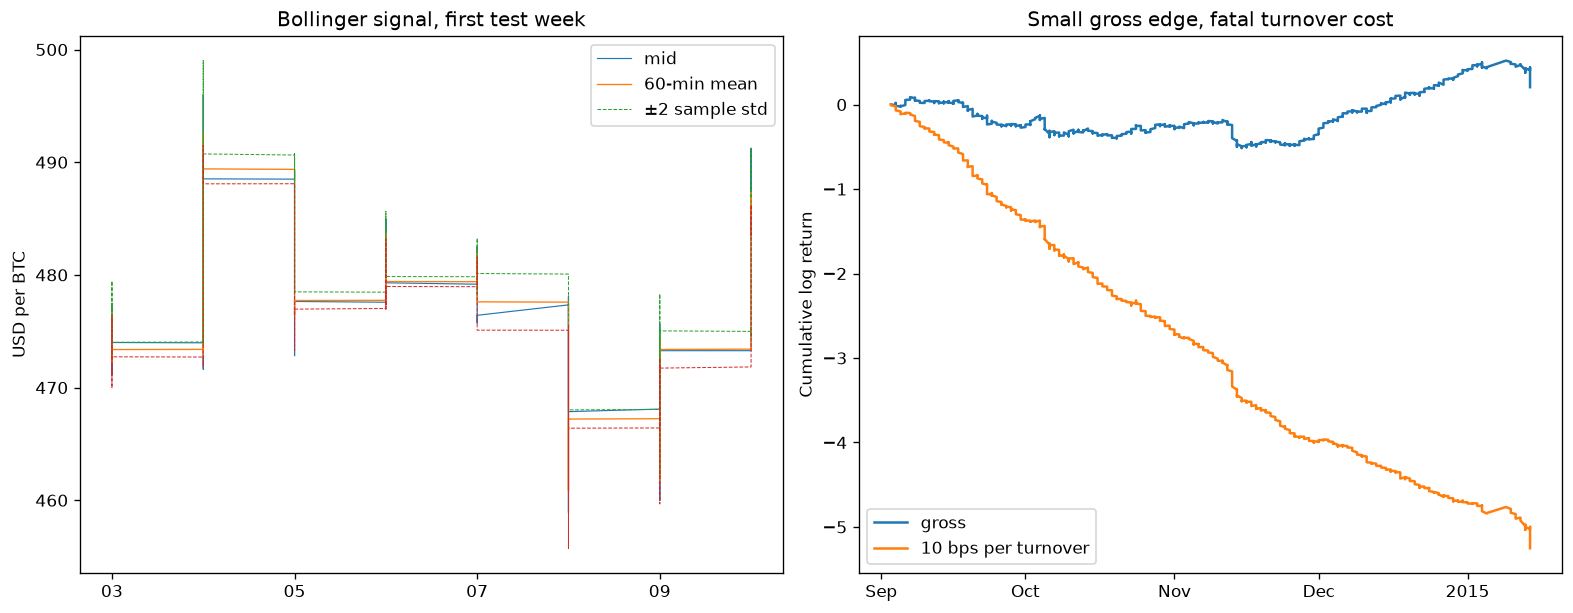

In [11]:
show_figure(ch7.plot_bollinger(data,results))

## 11. bagged regression tree adaptation

1·5·10·30·60분 과거 수익률로 다음 1분 수익률을 예측한다. 시간순 절반 split, tree 5개, minimum leaf 100, seed 1을 고정한다. sklearn RandomForestRegressor는 MATLAB TreeBagger와 bootstrap, split tie, random stream이 다르므로 source-semantic adaptation이다. in-sample prediction은 각 tree가 본 bootstrap 관측을 포함할 수 있어 독립 검증이 아니다.

In [12]:
pd.DataFrame({'train_gross':results['random_forest']['train']['performance'],'test_gross':results['random_forest']['test']['performance'],'test_net_10bps':results['random_forest']['test']['performance_net_10bps']}).T

,annual_return,annual_return_log,sharpe,maximum_drawdown,drawdown_duration,cumulative_return,cumulative_return_log,periods,periods_per_year
train_gross,3.203452e+71,164.647770,103.844456,-0.170136,399.0,4.084189e+32,75.089846,239707.0,525600.0
test_gross,2.230756e+16,37.643702,39.713356,-0.329454,6116.0,2.869454e+07,17.172217,239767.0,525600.0
test_net_10bps,-1.000000e+00,-435.104133,-410.603479,-1.000000,239765.0,-1.000000e+00,-198.484803,239767.0,525600.0


## 12. AI 결과의 경제성 stress test

gross test wealth와 Sharpe는 비현실적으로 크다. 그러나 position sign이 자주 바뀌어 10bp 비용을 차감한 cumulative log wealth는 붕괴한다. 모델의 MSE나 방향 정확도보다 turnover-adjusted P&L이 실제 목적함수에 가깝다. SVM은 fold-trained model 하나를 선택하고 전체 train에 refit하지 않으며, 100-network ensemble은 MATLAB training 기본값에 의존한다. 두 결과를 현대 Python 숫자로 억지 재현하지 않는다.

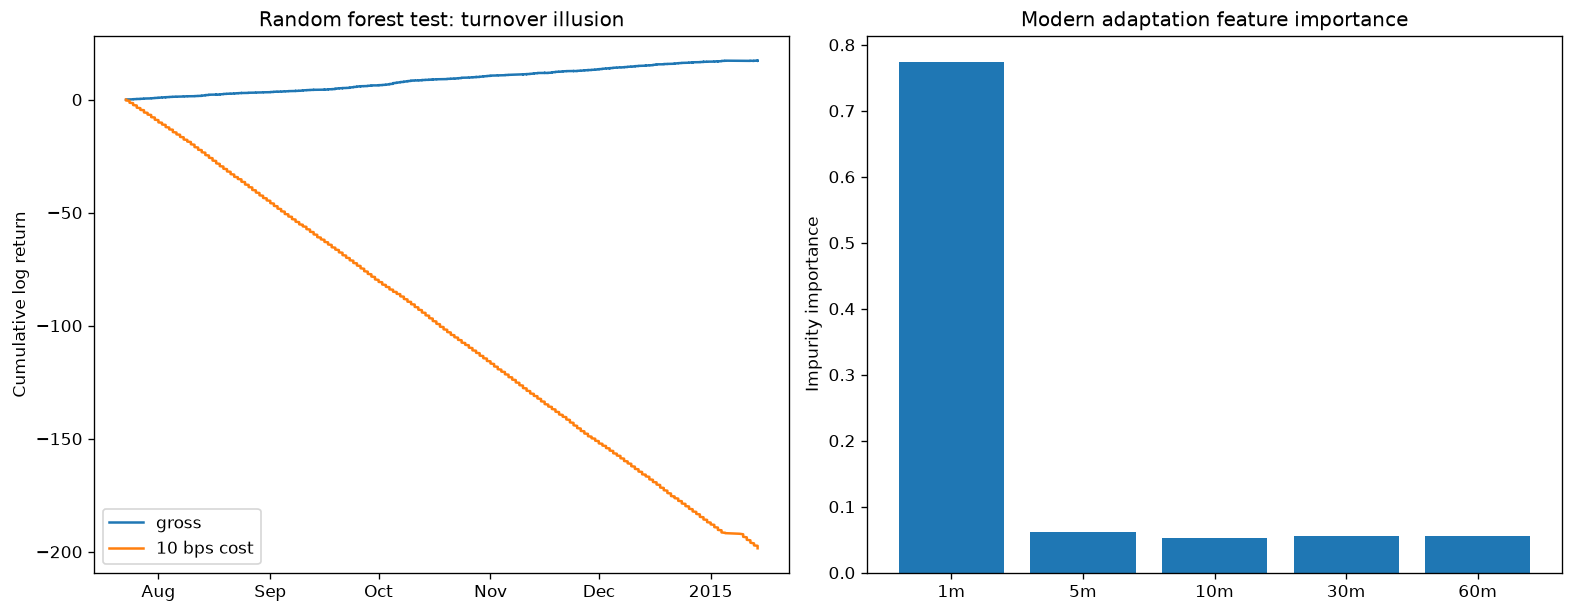

In [13]:
show_figure(ch7.plot_random_forest(data,results))

## 13. 수식 → 코드: 60초 order flow

aggressor side $s_i$와 size $v_i$를 이용해

$$OF_t=\sum_{t-60s<i\le t}s_i v_i$$

를 계산한다. `rolling_order_flow()`는 timestamp를 먼저 `datetime64[ns]`로 바꾼 뒤 integer search를 수행한다. Pandas 3의 내부 unit이 microsecond일 수 있으므로 단순 `astype(int64)`에 1e9를 곱한 경계를 적용하면 창이 틀어진다. 합성 0초·30초·61초 fixture가 현재 tick 포함과 왼쪽 경계를 검증한다.

In [14]:
pd.DataFrame(results['order_flow']['daily'])

,date,gross_pl_usd,num_trades,pl_per_trade_usd
0,20141201,5.90,6,0.983333
1,20141202,-3.63,8,-0.453750
2,20141203,-2.64,4,-0.660000
3,20141204,4.49,12,0.374167
4,20141205,0.12,12,0.010000
5,20141206,0.00,0,NaN
6,20141207,-1.25,2,-0.625000
7,20141208,1.68,20,0.084000
8,20141209,3.31,30,0.110333
9,20141210,1.46,7,0.208571


## 14. Bitstamp exact replay와 자정 state

60초 flow가 +90 BTC를 넘으면 long, -90 아래면 short, 0을 되돌아오면 청산한다. reversal은 기존 position 청산과 반대 진입을 합쳐 두 legs로 센다. 일별 realized P&L은 자정에 reset하지만 position과 entry price는 이어진다. 이 state contract로 31개 일별 P&L·trade count와 총 32.54달러, 336 legs가 원본과 일치한다. 자정에 position까지 reset하면 다른 결과가 된다.

gross_pl_usd                                                    32.54
pl_per_trade_usd                                             0.096845
num_trades                                                        336
ending_position                                                     0
cost_sensitivity    {'0.06_one_way': 12.380000000000248, '0.25_one...
dtype: object

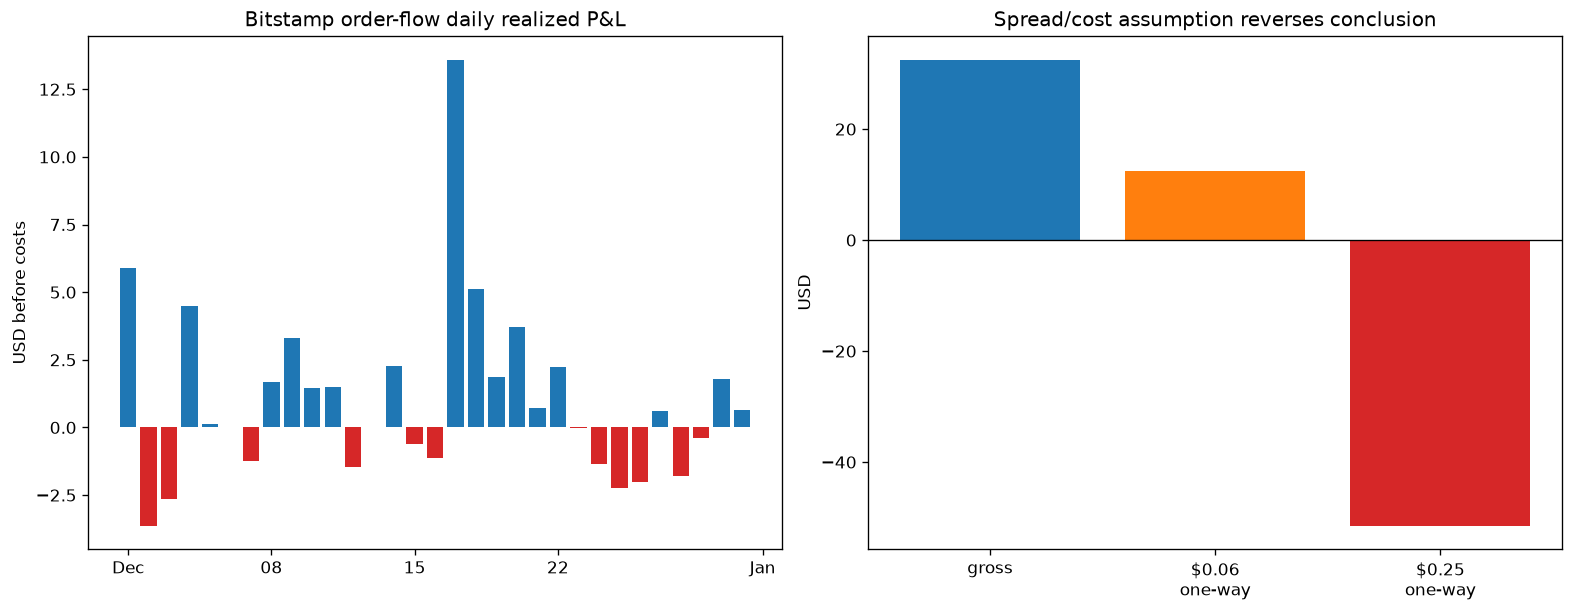

In [15]:
display(pd.Series({k:results['order_flow'][k] for k in ('gross_pl_usd','pl_per_trade_usd','num_trades','ending_position','cost_sensitivity')})); show_figure(ch7.plot_order_flow(data,results))

## 15. spread 설명의 모순과 비용 민감도

책 본문은 spread 약 0.12달러, one-way 0.06달러를 말하지만 원본 `orderFlow2.m`은 spread 약 0.5달러라고 주석한다. 어느 쪽을 임의로 진실로 선택하지 않는다. 각 leg 0.06달러에서는 gross 32.54달러가 12.38달러로 줄고, 0.25달러에서는 -51.46달러로 뒤집힌다. fee, spread, slippage, latency가 전략의 부속 항목이 아니라 결론을 결정한다.

In [16]:
pd.Series(results['arbitrage'])

historical_bitfinex_bid                           239.19
historical_btce_ask                              233.546
gross_spread_usd_per_btc                           5.644
stated_commission_usd                                1.0
stated_withdrawal_fee_usd                            2.0
illustrative_net_usd_per_btc                       2.644
credit_and_transfer_risk_quantified                False
historical_example_not_current_recommendation       True
dtype: object

## 16. cross-exchange arbitrage와 credit risk

역사적 Bitfinex bid 239.19와 btc-e ask 233.546의 차이는 BTC당 5.644달러다. 책의 commission 1달러와 withdrawal 2달러를 빼면 2.644달러지만 이는 동시에 양 거래소에 현금과 BTC inventory가 있고 출금이 정상이라는 가정이다. transfer delay, price move, counterparty default, withdrawal freeze, capital fragmentation은 식에 없다. 현재 시장 추천이나 무위험 수익이 아니다.

In [17]:
pd.DataFrame(metrics['reference_only_comparisons'])[['topic','source_file','compared','reason']]

,topic,source_file,compared,reason
0,AR and ARMA lag selection,buildARp_BTCUSD.m and buildARMA_findPQ_BTCUSD.m,False,MATLAB Gaussian ARIMA maximum-likelihood BIC i...
1,MATLAB TreeBagger results,rTreeBagger_BTCUSD.m,False,scikit-learn RandomForestRegressor is a determ...
2,cross-validated SVM,svm_BTCUSD.m,False,the script selects one fold-trained model rath...
3,100-network feed-forward ensemble,nn_feedfwd_avg_BTCUSD.m,False,the MATLAB neural-network training algorithm a...
4,"MXN, SPY, and HYG risk comparison",analyzeRisk.m,False,the official Chapter 7 archive contains BTC da...


## 17. 표본 외, selection bias, 연율화 한계

ARMA 90개 조합, SVM kernel, tree, NN을 같은 역사에서 탐색하면 selection bias가 커진다. 과거 rolling window에서만 모델을 선택하고 다음 window에 고정하는 walk-forward가 필요하다. 또한 원본 AR·Bollinger는 crypto minute return을 252일로, AI 예제는 365일로 연율화한다. CAGR, Sharpe, Calmar는 convention에 민감하므로 cumulative return, maximum drawdown, turnover와 비용을 함께 보고 비교 기준을 통일해야 한다.

In [18]:
pd.Series({'project_random_seed':ch7.RANDOM_SEED,'forest_random_seed':results['random_forest']['contract']['random_seed'],'tree_threads':1,'notebook_cell_ids':'deterministic'})

project_random_seed         20260718
forest_random_seed                 1
tree_threads                       1
notebook_cell_ids      deterministic
dtype: object

## 18. deterministic contract와 자동 verification

RandomForest seed=1, 프로젝트 random_seed=20260718, single-thread tree fit, deterministic notebook cell ID, PNG metadata를 고정한다. 25개 자동 검증은 archive checksum과 member 수, 원본 출력 비교, 31일 일별 order-flow, timestamp unit fixture, sample std, position lag, look-ahead 공개, 비용 단조성, output-only 사유를 포함한다. assert가 모두 참이어야 산출물을 완성한다.

In [19]:
verification=pd.Series(checks,name='passed'); display(verification); assert verification.all(); print(f"verification passed: {verification.sum()}/{len(verification)}")

archive_manifest_matches                            True
all_12_archive_members_pinned                       True
nine_matlab_sources_present                         True
minute_midprices_are_finite                         True
crossed_minute_quotes_are_disclosed                 True
hhmm_shape_mismatch_is_disclosed                    True
daily_dates_are_strictly_increasing                 True
trade_timestamps_are_monotonic                      True
all_numeric_source_comparisons_pass                 True
bollinger_uses_sample_standard_deviation            True
bollinger_cost_destroys_published_return            True
source_ar_lookahead_is_disclosed                    True
train_only_ar_does_not_use_test_prices              True
yule_walker_difference_is_not_called_exact          True
adf_does_not_reject_at_source_5pct_threshold        True
random_forest_is_deterministic_and_chronological    True
random_forest_cost_stress_is_worse                  True
order_flow_matches_all_31_daily

verification passed: 25/25


## 19. 결론

정확 재현된 결과 중 가장 중요한 것은 높은 gross 수익이 아니라 비용을 넣었을 때 결론이 뒤집힌다는 사실이다. AR full fit에는 look-ahead가 있고, estimator 선택은 lag를 바꾸며, minute BBO에는 shape mismatch와 crossed quote가 있다. order flow는 nanosecond와 자정 state를 정확히 고정해야 원본에 맞는다. Bitcoin 전략에서는 model complexity보다 데이터 contract, 표본 외 검증, execution cost, 거래소 credit와 withdrawal 가능성을 먼저 확인해야 한다.